<a href="https://colab.research.google.com/github/239y1a3931-sudo/NLP/blob/main/Day17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
def cosine_similarity(a,b):
  return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
good=np.array([0.82,0.41,0.10])
great=np.array([0.79,0.39,0.15])
bad=np.array([-0.71,-0.45,-0.05])
print(f'good vs great: {cosine_similarity(good,great):.3f}')
print(f'good vs bad : {cosine_similarity(good,bad):.3f}')
print(f'great vs bad : {cosine_similarity(great,bad):.3f}')


good vs great: 0.998
good vs bad : -0.994
great vs bad : -0.988


In [ ]:
!pip install gensim
from gensim.models import Word2Vec
# A small corpus — in practice use millions of sentences
sentences = [
'the king ruled the kingdom wisely',
'the queen ruled the land gracefully',
'the prince will become king one day',
'a man walked into the palace',
'a woman walked into the palace',
'the dog barked loudly in the garden',
'the puppy played happily in the garden',
]
# Tokenise each sentence into a list of words
tokenised = [s.split() for s in sentences]
# Train Word2Vec
# vector_size=50: each word gets a 50-number vector
# window=3: look 3 words left and right for context
# sg=1: use Skip-gram (sg=0 for CBOW)
# epochs=200: pass through the data 200 times
model = Word2Vec(sentences=tokenised, vector_size=50,
window=3, min_count=1, sg=1, epochs=200)
# Find top-3 most similar words to 'king'
print(model.wv.most_similar('king', topn=3))
# [('queen', 0.91), ('prince', 0.88), ('kingdom', 0.85)]
# The famous analogy: king - man + woman
result = model.wv.most_similar(
positive=['king', 'woman'], # add these
negative=['man'], # subtract this
topn=1
)
print('king - man + woman =', result[0][0]) # 'queen'


[('kingdom', 0.40141454339027405), ('played', 0.38476690649986267), ('in', 0.38395753502845764)]
king - man + woman = ruled


In [10]:
import sys
!{sys.executable} -m pip install gensim
# Step 0: Download GloVe vectors
# https://nlp.stanford.edu/data/glove.6B.zip (about 800 MB)
# Extract and you get: glove.6B.50d.txt, glove.6B.100d.txt, etc.
!wget --no-check-certificate https://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

# Step 1: Convert GloVe format to Word2Vec format (one-time step)
from gensim.scripts.glove2word2vec import glove2word2vec
glove2word2vec('glove.6B.100d.txt', 'glove.6B.100d.w2v.txt')
# Step 2: Load the converted file
from gensim.models import KeyedVectors
glove = KeyedVectors.load_word2vec_format(
'glove.6B.100d.w2v.txt', binary=False
) # Takes ~30 seconds; 400,000 words x 100 dimensions
# Step 3: Use it!
# --- Find top-5 most similar words ---
print(glove.most_similar('bollywood', topn=5))
# [('cinema', 0.82), ('films', 0.79), ('actors', 0.77), ...]
# --- Test analogy ---
res = glove.most_similar(positive=['paris','andhra'], negative=['france'],
topn=1)
print('paris - france + india =', res[0][0]) # hopefully 'delhi'!
# --- Cosine similarity between two words ---
print(glove.similarity('dog', 'puppy')) # ~0.81
print(glove.similarity('cat', 'cricket')) # ~0.12 (unrelated)


--2026-06-11 09:33:58--  https://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-06-11 09:33:59--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.1’

glove.6B.zip.1      100%[===================>] 822.24M  5.01MB/s    in 2m 39s  

2026-06-11 09:36:38 (5.17 MB/s) - ‘glove.6B.zip.1’ saved [862182613/862182613]

replace glove.6B.50d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

/tmp/ipykernel_5213/2111089112.py:11: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec('glove.6B.100d.txt', 'glove.6B.100d.w2v.txt')


KeyboardInterrupt: 

In [ ]:
import gensim.downloader as api
ft=api.load('fasttext-wiki-news-subwords-300')
print(ft.most_similar('king', topn=5))



[==================================================] 100.0% 958.5/958.4MB downloaded
[('king-', 0.7838029861450195), ('boy-king', 0.7704817652702332), ('queen', 0.7704246640205383), ('prince', 0.7700967192649841), ('kings', 0.7668929696083069)]


In [ ]:
import gensim.downloader as api
glove=api.load('glove-wiki-gigaword-50')
print(glove.most_similar('king', topn=5))

[==================================================] 100.0% 66.0/66.0MB downloaded
[('prince', 0.8236179351806641), ('queen', 0.7839043140411377), ('ii', 0.7746230363845825), ('emperor', 0.7736247777938843), ('son', 0.766719400882721)]


Missing words: {'shravanthparis', 'rama chandra'}
Vector matrix shape: (15, 100)


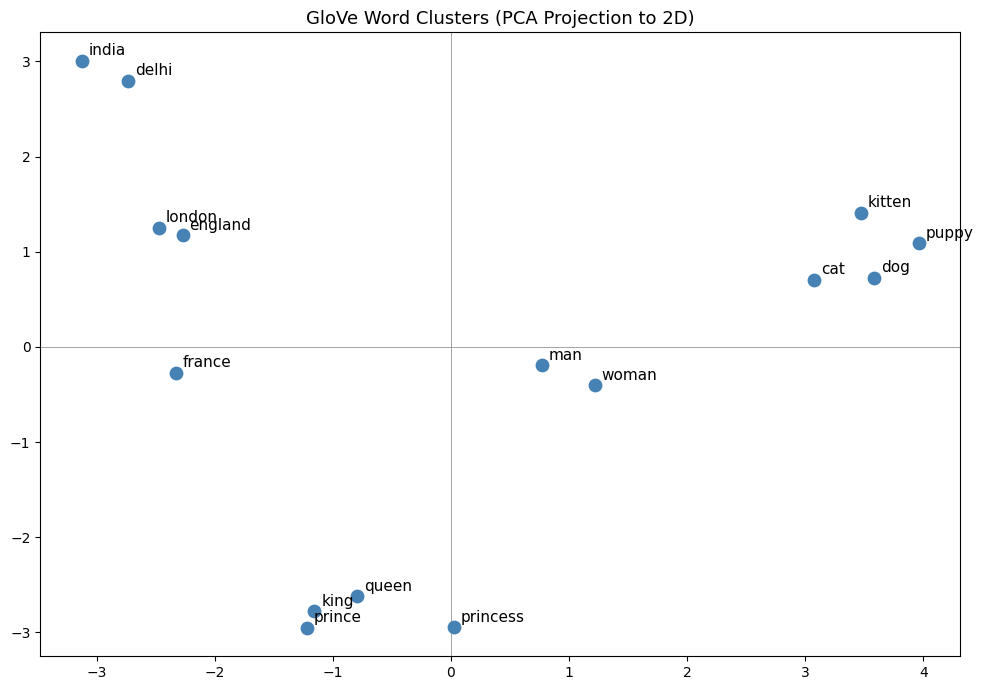

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from gensim.models import KeyedVectors

# Assuming you already loaded GloVe:
# glove = KeyedVectors.load_word2vec_format(
#     'glove.6B.100d.w2v.txt',
#     binary=False
# )

# Words to visualize
words = [
    'king', 'queen', 'man', 'woman', 'prince', 'princess',
    'dog', 'puppy', 'cat', 'kitten','rama chandra','shravanth'
    'paris', 'france', 'delhi', 'india', 'london', 'england'
]

# Keep only words that exist in the model
valid_words = [w for w in words if w in glove.key_to_index]

missing_words = set(words) - set(valid_words)
if missing_words:
    print("Missing words:", missing_words)

# Extract vectors
vectors = np.array([glove[w] for w in valid_words])

print("Vector matrix shape:", vectors.shape)

# Reduce dimensions from 100D -> 2D
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    coords[:, 0],
    coords[:, 1],
    s=80,
    color='steelblue',
    zorder=3
)

# Add labels
for i, word in enumerate(valid_words):
    ax.annotate(
        word,
        (coords[i, 0], coords[i, 1]),
        fontsize=11,
        xytext=(5, 4),
        textcoords='offset points'
    )

ax.set_title(
    'GloVe Word Clusters (PCA Projection to 2D)',
    fontsize=13
)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig('word_clusters.png', dpi=150)
plt.show()

In [4]:
import numpy as np

def sentence_vector(sentence, model, dim=100):
    '''
    Convert a sentence to a single vector by averaging its word vectors.
    Words not in the vocabulary are silently skipped.
    '''
    tokens = sentence.lower().split()  # tokenise

    vectors = []

    for token in tokens:
        if token in model:  # only use words we have vectors for
            vectors.append(model[token])  # model[token] returns a 100-D array

    if not vectors:  # if ALL words are unknown
        return np.zeros(dim)  # return a zero vector as fallback

    return np.mean(vectors, axis=0)  # element-wise average across all words


# Test it
s1 = 'movie was fantastic'
s2 = 'movie was romatic comdey'
s3 = 'A romantic comedy about falling in love in Paris'

v1 = sentence_vector(s1, glove)
v2 = sentence_vector(s2, glove)
v3 = sentence_vector(s3, glove)

# Compare similarity
from numpy.linalg import norm

cos = lambda a, b: np.dot(a, b) / (norm(a) * norm(b))  # cosine similarity

print(f's1 vs s2 (both action): {cos(v1, v2):.3f}')  # high ~0.93
print(f's1 vs s3 (action vs romance): {cos(v1, v3):.3f}')  # lower ~0.61

# The model correctly identifies that s1 and s2 are more similar!

s1 vs s2 (both action): 0.952
s1 vs s3 (action vs romance): 0.827


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
# df has columns: 'description' (text) and 'genre' (label)

df = pd.DataFrame({
    "description": [
        "A brave warrior saves humanity from destruction",
        "A hero fights evil forces to protect the world",
        "Two strangers fall in love in Paris",
        "A romantic story about relationships and emotions",
        "A hilarious comedy full of funny situations",
        "Friends experience a series of humorous adventures",
        "A detective investigates a mysterious murder case",
        "A criminal conspiracy shocks the entire city"
    ],
    "genre": [
        "action",
        "action",
        "romance",
        "romance",
        "comedy",
        "comedy",
        "crime",
        "crime"
    ]
})
# Build one 100-D vector per movie description
# This replaces TF-IDF — instead of word counts, we use semantic meaning
X = np.array([sentence_vector(desc, glove) for desc in df['description']])
y = df['genre'] # e.g. 'action', 'romance', 'comedy'
# Standard train/test split
X_tr, X_te, y_tr, y_te = train_test_split(
X, y, test_size=0.5, random_state=42, stratify=y
)
# Logistic Regression on semantic vectors
clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_tr, y_tr)
print(classification_report(y_te, clf.predict(X_te)))
# Embedding-based model beats TF-IDF on unseen vocabulary!


              precision    recall  f1-score   support

      action       1.00      1.00      1.00         1
      comedy       1.00      1.00      1.00         1
       crime       1.00      1.00      1.00         1
     romance       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [7]:
import numpy as np
import pandas as pd
from gensim.models import KeyedVectors
# Load pre-trained GloVe (100 dimensions)
glove = KeyedVectors.load_word2vec_format('glove.6B.100d.w2v.txt',binary=False)
# Our movie dataset — Bollywood + Hollywood
movies = [
# Bollywood
{'title':'Dilwale Dulhania Le Jayenge',
'desc':'A young man follows the woman he loves to India after they fall inlove in Europe'},
{'title':'Lagaan',
'desc':'Villagers challenge British colonisers to a cricket match to avoipaying heavy taxes'},
{'title':'Dangal',
'desc':'A father trains his daughters to become world class wrestlers against all odds'},
{'title':'3 Idiots',
'desc':'Three college friends question the pressure of engineering education in India'},
{'title':'Dil Chahta Hai',
'desc':'Three best friends navigate love relationships and life after graduation'},
# Hollywood
{'title':'Titanic',
'desc':'A wealthy girl and a poor artist fall in love on a doomed ocean liner'},
{'title':'Rocky',
'desc':'An underdog boxer trains relentlessly for a shot at the world heavyweight champion'},
{'title':'Good Will Hunting',
'desc':'A genius janitor from Boston works through emotional trauma with a therapist'},
{'title':'Chariots of Fire',
'desc':'Two British athletes train and compete for glory in the 1924 Olympic Games'},
{'title':'                                                                                                                                  ',
'desc':'Two strangers meet on a train in Europe and spend one romantic night in Vienna'},
]
df = pd.DataFrame(movies)
print(df[['title']].to_string())

                                                                                                                                title
0                                                                                                         Dilwale Dulhania Le Jayenge
1                                                                                                                              Lagaan
2                                                                                                                              Dangal
3                                                                                                                            3 Idiots
4                                                                                                                      Dil Chahta Hai
5                                                                                                                             Titanic
6                                                             

In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def sentence_vector(text, model, dim=100):
    tokens = text.lower().split()
    vectors = [model[word] for word in tokens if word in model]

    if len(vectors) > 0:
        return np.mean(vectors, axis=0)

    return np.zeros(dim)

# Create vectors for all movie descriptions
df["vector"] = df["desc"].apply(lambda x: sentence_vector(x, glove))

# Stack vectors into a matrix
V = np.vstack(df["vector"].values)

def find_similar(query_desc, df, V, model, top_n=3):
    query_vector = sentence_vector(query_desc, model).reshape(1, -1)

    similarities = cosine_similarity(query_vector, V)[0]

    top_indices = np.argsort(similarities)[::-1][:top_n]

    result = df.iloc[top_indices][["title"]].copy()
    result["similarity"] = similarities[top_indices].round(3)

    return result

# Query 1
query1 = "An underdog athlete trains hard and wins against all expectations"
print("QUERY:", query1)
print(find_similar(query1, df, V, glove))

# Query 2
query2 = "Two people fall in love while travelling across Europe"
print("\nQUERY:", query2)
print(find_similar(query2, df, V, glove))


QUERY: An underdog athlete trains hard and wins against all expectations
              title  similarity
6             Rocky       0.927
2            Dangal       0.926
8  Chariots of Fire       0.911

QUERY: Two people fall in love while travelling across Europe
                                               title  similarity
9                                                ...       0.955
0                        Dilwale Dulhania Le Jayenge       0.935
5                                            Titanic       0.905


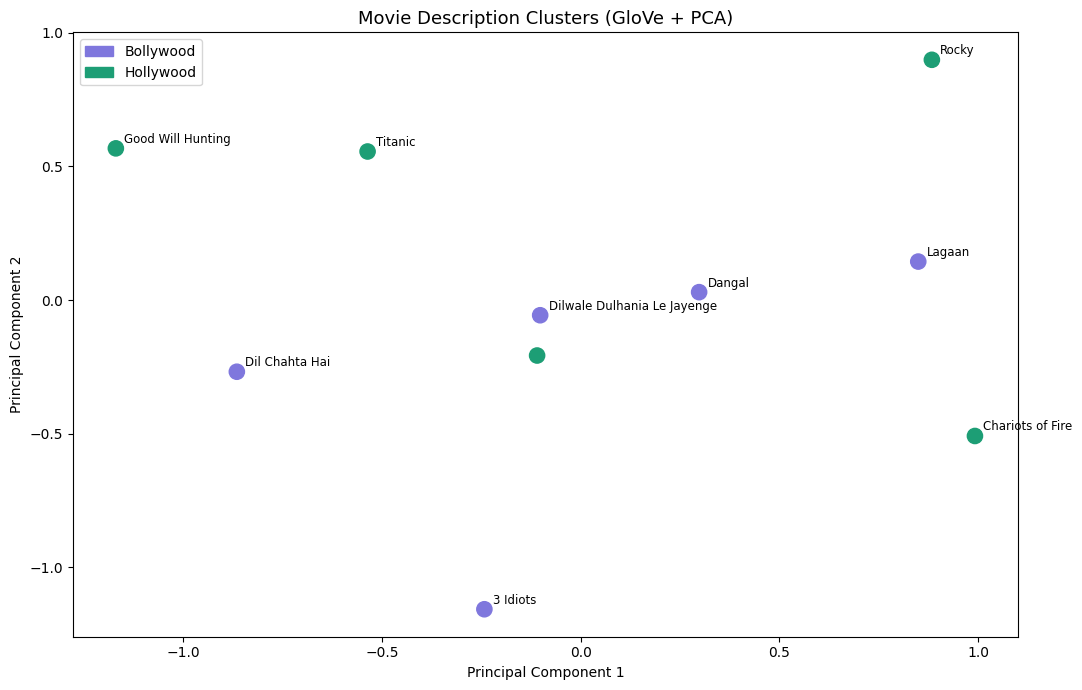

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA

# Reduce 100-D vectors to 2D
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(V)  # shape: (n_movies, 2)

# Colors: first 5 Bollywood, next 5 Hollywood
colours = ['#7F77DD'] * 5 + ['#1D9E75'] * 5

# Create plot
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    coords[:, 0],
    coords[:, 1],
    c=colours,
    s=120,
    zorder=3
)

# Add movie titles
for i, row in df.iterrows():
    ax.annotate(
        row['title'],
        (coords[i, 0], coords[i, 1]),
        fontsize=8.5,
        xytext=(6, 4),
        textcoords='offset points'
    )

# Legend
ax.legend(
    handles=[
        mpatches.Patch(color='#7F77DD', label='Bollywood'),
        mpatches.Patch(color='#1D9E75', label='Hollywood')
    ],
    fontsize=10
)

ax.set_title('Movie Description Clusters (GloVe + PCA)', fontsize=13)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')

plt.tight_layout()

plt.savefig('movie_clusters.png', dpi=150)
plt.show()